Loaded 1892 rows from 946 CSVs
Columns: ['Patient', 'Data_seed', 'Reservoir_seed', 'input_len', 'Pred_len', 'N', 'n_train_windows', 'hostname', 'cpu_model', 'cpu_logical', 'cpu_physical', 'cpu_freq_mhz', 'ram_total_gb', 'platform', 'python_version', 'numpy_version', 'train_time_s', 'latency_ep_mean_ms', 'latency_ep_std_ms', 'realtime_req_ms', 'ep_feasible', 'beat_step_mean_ms', 'beat_step_std_ms', 'total_loop_time_ms', 'beat_duration_ms', 'latency_ratio', 'final_f1', 'final_precision', 'final_recall', 'final_accuracy', 'auc_f1', 'peak_f1', 'Online_results', 'S_kb', 'R_kb', 'params_kb', 'pca_kb', 'total_model_kb', 'peak_ram_kb']
           Patient            N    Pred_len  latency_ep_mean_ms  train_time_s  \
count  1892.000000  1892.000000  1892.00000         1892.000000   1892.000000   
mean    193.163848    27.473573     5.50000           28.503406   2148.796629   
std      41.205392    14.344918     4.50119            7.667593    596.285707   
min     106.000000     5.000000     1.00

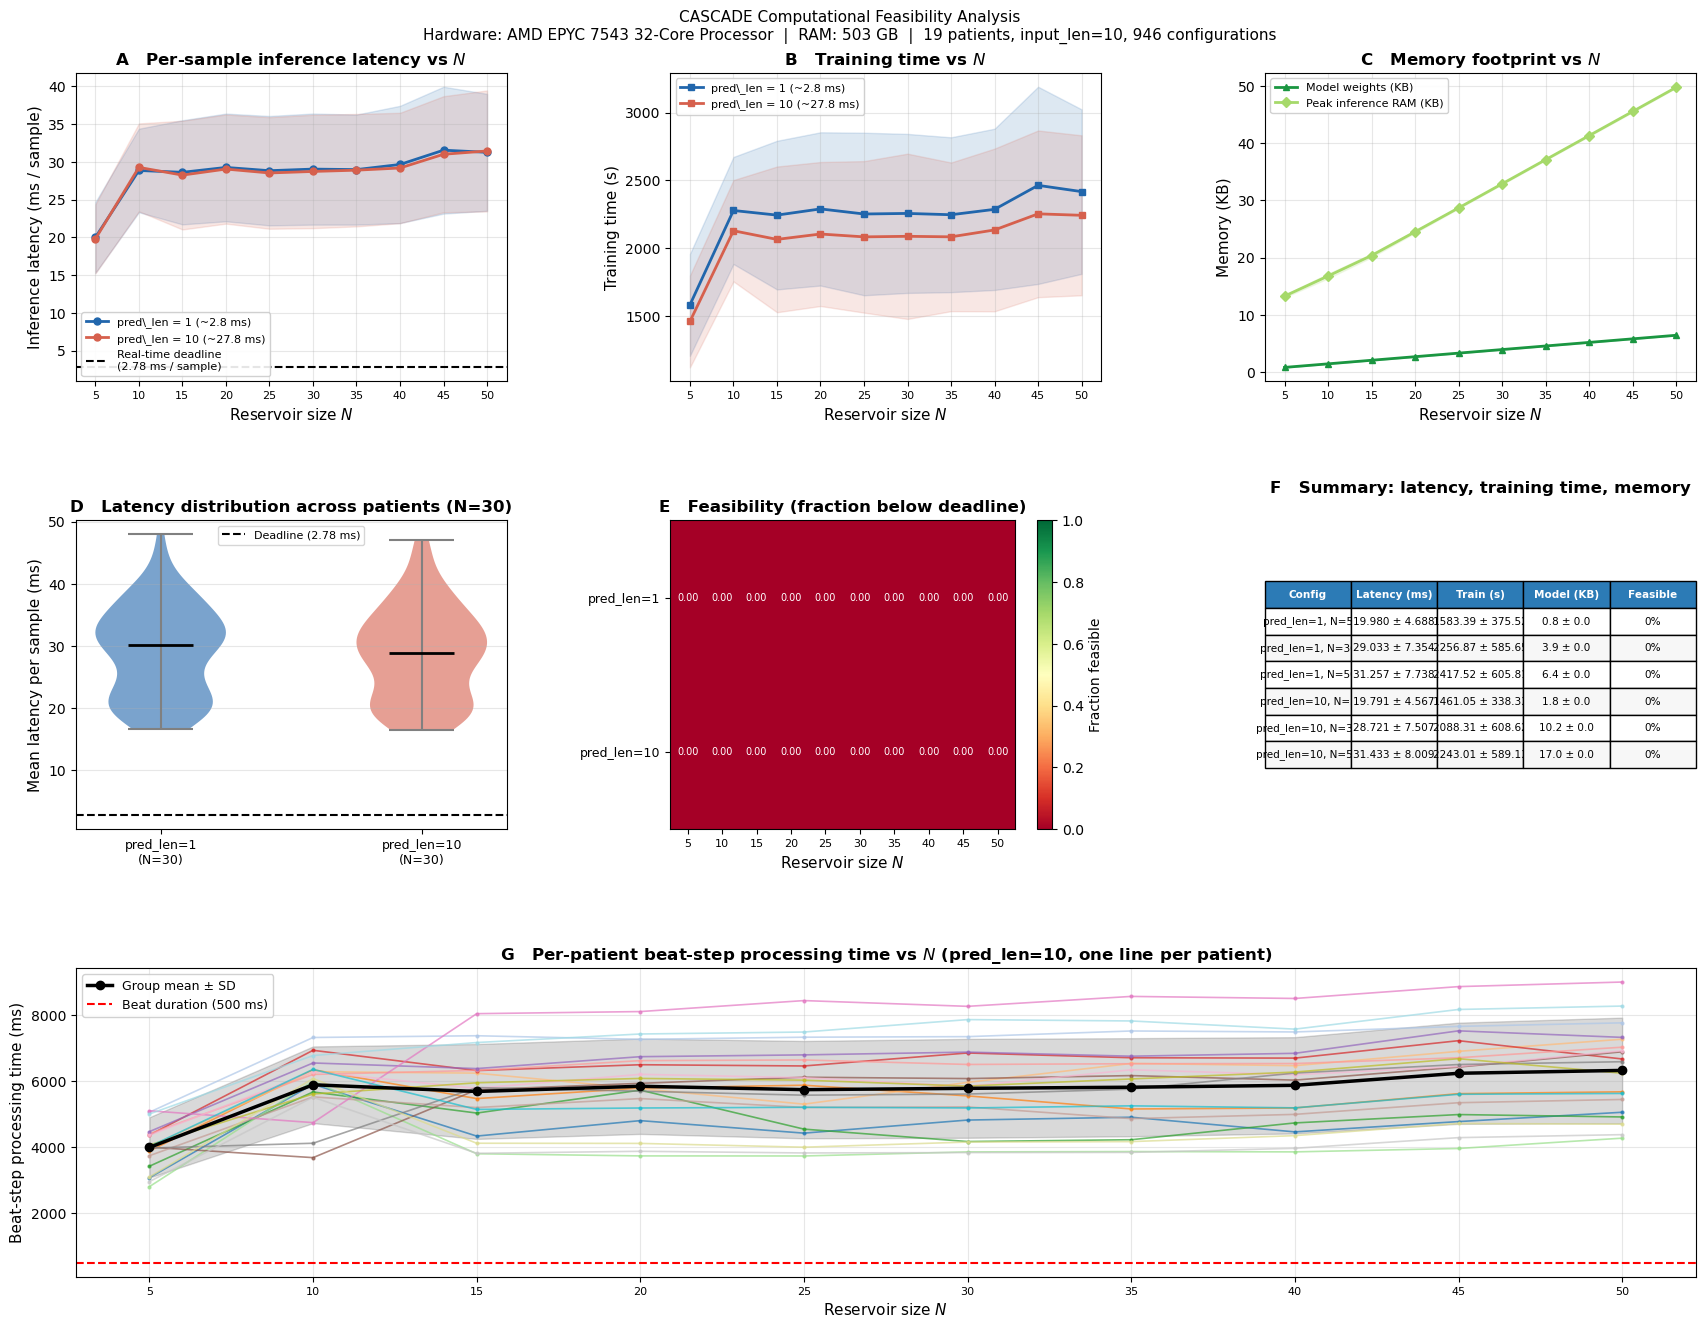


PAPER-READY NUMBERS

pred_len = 1:
  Inference latency : 28.598 ± 7.667 ms (min 10.041, max 63.058)
  Training time     : 2232.36 ± 606.08 s
  Model memory      : 3.6 ± 1.8 KB (0.004 MB)
  Feasible (<2.78 ms): 0.0% of configurations

pred_len = 10:
  Inference latency : 28.409 ± 7.672 ms (min 10.411, max 50.280)
  Training time     : 2065.23 ± 574.61 s
  Model memory      : 9.4 ± 4.8 KB (0.009 MB)
  Feasible (<2.78 ms): 0.0% of configurations

Real-time deadline  : 2.778 ms/sample (at 360 Hz)
Beat duration       : 500.0 ms
N range tested      : 5 – 50


In [1]:
#!/usr/bin/env python
# coding: utf-8
"""
Generate computational feasibility figure for CASCADE timing analysis.
Reads all CSVs from results_timing/ and produces a multi-panel figure
addressing Reviewer Comment 7 (online/real-time claims).

Panel A: Per-sample inference latency (ms) vs N, coloured by pred_len
          with real-time deadline line (1000/360 ≈ 2.78 ms)
Panel B: Training time (s) vs N
Panel C: Total model memory footprint (KB) vs N
Panel D: Latency distribution across patients (violin) at fixed N,
          both pred_lens, with deadline line
Panel E: Feasibility heatmap — fraction of (patient, seed) combos
          where mean EP latency < real-time deadline, across N values
Panel F: Text/table summary box (mean ± std of key metrics)
"""

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# ── 1. LOAD ALL TIMING CSVs ────────────────────────────────────────────────

RESULTS_DIR = "results_timing"
csv_files   = glob.glob(os.path.join(RESULTS_DIR, "timing_*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No timing CSVs found in {RESULTS_DIR}/")

df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
print(f"Loaded {len(df)} rows from {len(csv_files)} CSVs")
print(f"Columns: {list(df.columns)}")
print(df[["Patient","N","Pred_len","latency_ep_mean_ms","train_time_s",
          "total_model_kb","peak_ram_kb"]].describe())

# ── 2. DERIVED QUANTITIES ──────────────────────────────────────────────────

FS              = 360                        # Hz
DEADLINE_MS     = 1000.0 / FS               # 2.778 ms per sample
BEAT_DURATION_MS = 180 * 1000.0 / FS        # 500 ms per beat

df["feasible"]         = df["latency_ep_mean_ms"] < DEADLINE_MS
df["latency_ep_us"]    = df["latency_ep_mean_ms"] * 1000   # µs for display
df["total_model_mb"]   = df["total_model_kb"] / 1024

pred_lens = sorted(df["Pred_len"].unique())
N_values  = sorted(df["N"].unique())
patients  = sorted(df["Patient"].unique())

# colour map for pred_len
CMAP  = {1: "#2166ac", 10: "#d6604d"}
LABEL = {1: "pred\\_len = 1 (~2.8 ms)", 10: "pred\\_len = 10 (~27.8 ms)"}

# fixed N for violin (choose median N)
N_violin = N_values[len(N_values)//2]

# ── 3. AGGREGATION HELPERS ─────────────────────────────────────────────────

def agg_by_N(df_sub, col):
    """Return mean ± std per N value."""
    g   = df_sub.groupby("N")[col]
    return g.mean(), g.std()

# ── 4. FIGURE LAYOUT ───────────────────────────────────────────────────────

fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor("white")

gs = gridspec.GridSpec(
    3, 3,
    figure=fig,
    hspace=0.45, wspace=0.38,
    left=0.07, right=0.97, top=0.93, bottom=0.07
)

ax_A = fig.add_subplot(gs[0, 0])   # latency vs N
ax_B = fig.add_subplot(gs[0, 1])   # train time vs N
ax_C = fig.add_subplot(gs[0, 2])   # memory vs N
ax_D = fig.add_subplot(gs[1, 0])   # violin latency across patients
ax_E = fig.add_subplot(gs[1, 1])   # feasibility heatmap
ax_F = fig.add_subplot(gs[1, 2])   # summary table
ax_G = fig.add_subplot(gs[2, :])   # latency ratio / beat-step time across patients

# ── PANEL A: Inference latency vs N ───────────────────────────────────────

for pl in pred_lens:
    sub       = df[df["Pred_len"] == pl]
    mn, sd    = agg_by_N(sub, "latency_ep_mean_ms")
    ax_A.plot(mn.index, mn.values, color=CMAP[pl], lw=2,
              marker='o', ms=5, label=LABEL[pl])
    ax_A.fill_between(mn.index,
                      (mn - sd).clip(lower=0),
                      mn + sd,
                      color=CMAP[pl], alpha=0.15)

ax_A.axhline(DEADLINE_MS, color="black", lw=1.5, ls="--",
             label=f"Real-time deadline\n({DEADLINE_MS:.2f} ms / sample)")
ax_A.set_xlabel("Reservoir size $N$", fontsize=11)
ax_A.set_ylabel("Inference latency (ms / sample)", fontsize=11)
ax_A.set_title("A   Per-sample inference latency vs $N$", fontsize=12, fontweight='bold')
ax_A.legend(fontsize=8, framealpha=0.9)
ax_A.set_xticks(N_values)
ax_A.tick_params(axis='x', labelsize=8)
ax_A.grid(True, alpha=0.3)

# ── PANEL B: Training time vs N ───────────────────────────────────────────

for pl in pred_lens:
    sub    = df[df["Pred_len"] == pl]
    mn, sd = agg_by_N(sub, "train_time_s")
    ax_B.plot(mn.index, mn.values, color=CMAP[pl], lw=2,
              marker='s', ms=5, label=LABEL[pl])
    ax_B.fill_between(mn.index,
                      (mn - sd).clip(lower=0),
                      mn + sd,
                      color=CMAP[pl], alpha=0.15)

ax_B.set_xlabel("Reservoir size $N$", fontsize=11)
ax_B.set_ylabel("Training time (s)", fontsize=11)
ax_B.set_title("B   Training time vs $N$", fontsize=12, fontweight='bold')
ax_B.legend(fontsize=8, framealpha=0.9)
ax_B.set_xticks(N_values)
ax_B.tick_params(axis='x', labelsize=8)
ax_B.grid(True, alpha=0.3)

# ── PANEL C: Memory footprint vs N ────────────────────────────────────────

# memory is pred_len-independent (model size), use pred_len=1
sub_mem = df[df["Pred_len"] == pred_lens[0]]
mn_m, sd_m = agg_by_N(sub_mem, "total_model_kb")
mn_p, sd_p = agg_by_N(sub_mem, "peak_ram_kb")

ax_C.plot(mn_m.index, mn_m.values, color="#1a9641", lw=2,
          marker='^', ms=5, label="Model weights (KB)")
ax_C.fill_between(mn_m.index,
                  (mn_m - sd_m).clip(lower=0),
                  mn_m + sd_m,
                  color="#1a9641", alpha=0.15)

ax_C.plot(mn_p.index, mn_p.values, color="#a6d96a", lw=2,
          marker='D', ms=5, label="Peak inference RAM (KB)")
ax_C.fill_between(mn_p.index,
                  (mn_p - sd_p).clip(lower=0),
                  mn_p + sd_p,
                  color="#a6d96a", alpha=0.15)

ax_C.set_xlabel("Reservoir size $N$", fontsize=11)
ax_C.set_ylabel("Memory (KB)", fontsize=11)
ax_C.set_title("C   Memory footprint vs $N$", fontsize=12, fontweight='bold')
ax_C.legend(fontsize=8, framealpha=0.9)
ax_C.set_xticks(N_values)
ax_C.tick_params(axis='x', labelsize=8)
ax_C.grid(True, alpha=0.3)

# ── PANEL D: Violin — latency distribution across patients ─────────────────

vdata, vlabels, vcolors = [], [], []
for pl in pred_lens:
    sub = df[(df["Pred_len"] == pl) & (df["N"] == N_violin)]
    vdata.append(sub["latency_ep_mean_ms"].dropna().values)
    vlabels.append(f"pred_len={pl}\n(N={N_violin})")
    vcolors.append(CMAP[pl])

vp = ax_D.violinplot(vdata, positions=range(len(vdata)),
                     showmedians=True, showextrema=True)

for i, (body, col) in enumerate(zip(vp['bodies'], vcolors)):
    body.set_facecolor(col)
    body.set_alpha(0.6)
vp['cmedians'].set_color('black')
vp['cmedians'].set_linewidth(2)
for part in ['cbars', 'cmins', 'cmaxes']:
    vp[part].set_color('gray')

ax_D.axhline(DEADLINE_MS, color="black", lw=1.5, ls="--",
             label=f"Deadline ({DEADLINE_MS:.2f} ms)")
ax_D.set_xticks(range(len(vdata)))
ax_D.set_xticklabels(vlabels, fontsize=9)
ax_D.set_ylabel("Mean latency per sample (ms)", fontsize=11)
ax_D.set_title(f"D   Latency distribution across patients (N={N_violin})",
               fontsize=12, fontweight='bold')
ax_D.legend(fontsize=8)
ax_D.grid(True, alpha=0.3, axis='y')

# ── PANEL E: Feasibility heatmap ───────────────────────────────────────────

feas_mat = np.zeros((len(pred_lens), len(N_values)))
for i, pl in enumerate(pred_lens):
    for j, n in enumerate(N_values):
        sub = df[(df["Pred_len"] == pl) & (df["N"] == n)]
        if len(sub) > 0:
            feas_mat[i, j] = sub["feasible"].mean()

im = ax_E.imshow(feas_mat, aspect='auto', cmap='RdYlGn',
                 vmin=0, vmax=1, origin='upper')
ax_E.set_xticks(range(len(N_values)))
ax_E.set_xticklabels(N_values, fontsize=8)
ax_E.set_yticks(range(len(pred_lens)))
ax_E.set_yticklabels([f"pred_len={pl}" for pl in pred_lens], fontsize=9)
ax_E.set_xlabel("Reservoir size $N$", fontsize=11)
ax_E.set_title("E   Feasibility (fraction below deadline)", fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax_E, label="Fraction feasible")

for i in range(len(pred_lens)):
    for j in range(len(N_values)):
        ax_E.text(j, i, f"{feas_mat[i,j]:.2f}",
                  ha='center', va='center', fontsize=7,
                  color='black' if 0.3 < feas_mat[i,j] < 0.7 else 'white')

# ── PANEL F: Summary statistics table ─────────────────────────────────────

ax_F.axis('off')

rows = []
for pl in pred_lens:
    sub = df[df["Pred_len"] == pl]
    # use smallest and largest N for summary
    for n_sel in [N_values[0], N_values[len(N_values)//2], N_values[-1]]:
        s = sub[sub["N"] == n_sel]
        if len(s) == 0:
            continue
        rows.append([
            f"pred_len={pl}, N={n_sel}",
            f"{s['latency_ep_mean_ms'].mean():.3f} ± {s['latency_ep_mean_ms'].std():.3f}",
            f"{s['train_time_s'].mean():.2f} ± {s['train_time_s'].std():.2f}",
            f"{s['total_model_kb'].mean():.1f} ± {s['total_model_kb'].std():.1f}",
            f"{int(s['feasible'].mean()*100)}%",
        ])

col_labels = ["Config", "Latency (ms)", "Train (s)", "Model (KB)", "Feasible"]
tbl = ax_F.table(
    cellText=rows,
    colLabels=col_labels,
    loc='center',
    cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(7.5)
tbl.scale(1, 1.6)

# header row styling
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor("#2c7bb6")
    tbl[0, j].set_text_props(color='white', fontweight='bold')

# alternate row shading
for i in range(1, len(rows)+1):
    for j in range(len(col_labels)):
        tbl[i, j].set_facecolor("#f7f7f7" if i % 2 == 0 else "white")

ax_F.set_title("F   Summary: latency, training time, memory",
               fontsize=12, fontweight='bold', pad=20)

# ── PANEL G: Per-patient beat-step time vs N (both pred_lens, boxplot) ─────

# Show mean beat_step_mean_ms per patient at each N, one line per patient
# Use pred_len=10 (harder case)
sub_g = df[df["Pred_len"] == pred_lens[-1]]   # pred_len=10

pat_list = sorted(sub_g["Patient"].unique())
cmap_pat = plt.cm.tab20(np.linspace(0, 1, len(pat_list)))

for pat, col in zip(pat_list, cmap_pat):
    p_sub   = sub_g[sub_g["Patient"] == pat]
    mn_bs   = p_sub.groupby("N")["beat_step_mean_ms"].mean()
    ax_G.plot(mn_bs.index, mn_bs.values,
              color=col, lw=1.2, alpha=0.7, marker='.', ms=4)

# group mean
mn_grp = sub_g.groupby("N")["beat_step_mean_ms"].mean()
sd_grp = sub_g.groupby("N")["beat_step_mean_ms"].std()
ax_G.plot(mn_grp.index, mn_grp.values,
          color='black', lw=2.5, marker='o', ms=6, label="Group mean ± SD", zorder=5)
ax_G.fill_between(mn_grp.index,
                  (mn_grp - sd_grp).clip(lower=0),
                  mn_grp + sd_grp,
                  color='black', alpha=0.15)

ax_G.axhline(BEAT_DURATION_MS, color="red", lw=1.5, ls="--",
             label=f"Beat duration ({BEAT_DURATION_MS:.0f} ms)")
ax_G.set_xlabel("Reservoir size $N$", fontsize=11)
ax_G.set_ylabel("Beat-step processing time (ms)", fontsize=11)
ax_G.set_title(
    "G   Per-patient beat-step processing time vs $N$ "
    f"(pred_len={pred_lens[-1]}, one line per patient)",
    fontsize=12, fontweight='bold'
)
ax_G.set_xticks(N_values)
ax_G.tick_params(axis='x', labelsize=8)
ax_G.legend(fontsize=9, framealpha=0.9)
ax_G.grid(True, alpha=0.3)

# ── 5. GLOBAL TITLE & SAVE ─────────────────────────────────────────────────

# grab hardware info from first row
hw_str = df["cpu_model"].iloc[0] if "cpu_model" in df.columns else "unknown CPU"
ram_gb = df["ram_total_gb"].iloc[0] if "ram_total_gb" in df.columns else "?"

fig.suptitle(
    "CASCADE Computational Feasibility Analysis\n"
    f"Hardware: {hw_str}  |  RAM: {ram_gb:.0f} GB  |  "
    f"{len(patients)} patients, input_len=10, {len(csv_files)} configurations",
    fontsize=11, y=0.975
)

out_path = "Fig_timing_feasibility.pdf"
fig.savefig(out_path, dpi=300, bbox_inches='tight')
fig.savefig(out_path.replace(".pdf", ".png"), dpi=300, bbox_inches='tight')
print(f"Saved: {out_path}")
plt.show()

# ── 6. PRINT PAPER-READY NUMBERS ──────────────────────────────────────────

print("\n" + "="*60)
print("PAPER-READY NUMBERS")
print("="*60)

for pl in pred_lens:
    sub = df[df["Pred_len"] == pl]
    lat = sub["latency_ep_mean_ms"]
    trn = sub["train_time_s"]
    mem = sub["total_model_kb"]
    fea = sub["feasible"].mean() * 100
    print(f"\npred_len = {pl}:")
    print(f"  Inference latency : {lat.mean():.3f} ± {lat.std():.3f} ms "
          f"(min {lat.min():.3f}, max {lat.max():.3f})")
    print(f"  Training time     : {trn.mean():.2f} ± {trn.std():.2f} s")
    print(f"  Model memory      : {mem.mean():.1f} ± {mem.std():.1f} KB "
          f"({mem.mean()/1024:.3f} MB)")
    print(f"  Feasible (<{DEADLINE_MS:.2f} ms): {fea:.1f}% of configurations")

print(f"\nReal-time deadline  : {DEADLINE_MS:.3f} ms/sample (at {FS} Hz)")
print(f"Beat duration       : {BEAT_DURATION_MS:.1f} ms")
print(f"N range tested      : {N_values[0]} – {N_values[-1]}")